In [ ]:
# CELL 1 - IMPORT LIBRARY

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import backend as K

tf.random.set_seed(42)
np.random.seed(42)

print("=" * 70)
print("  PREDIKSI SISA STOK GUDANG PUPUK BERSUBSIDI — LSTM REGRESI (DATA BARU)")
print("  Kios Tani Gunung Salak, Kalapanunggal, Kab. Sukabumi")
print("=" * 70)
print(f"  TensorFlow : {tf.__version__}")
print(f"  Pandas     : {pd.__version__}")
print("  Library siap.")


  PREDIKSI SISA STOK GUDANG PUPUK BERSUBSIDI — LSTM REGRESI (DATA BARU)
  Kios Tani Gunung Salak, Kalapanunggal, Kab. Sukabumi
  TensorFlow : 2.20.0
  Pandas     : 2.2.3
  Library siap.


In [ ]:
# CELL 2 - UPLOAD FILE EXCEL

from google.colab import files

print("\nUpload file DATA_GABUNGAN_STOK_PENYALURAN_HARIAN.xlsx\n")
uploaded = files.upload()

nama_file = list(uploaded.keys())[0]
df_raw = pd.read_excel(nama_file)

print(f"\nFile berhasil dibaca: {nama_file}")
print(f"Kolom: {df_raw.columns.tolist()}")
print(f"Jumlah baris awal: {len(df_raw)}")
display(df_raw.head())


Upload file DATA_GABUNGAN_STOK_PENYALURAN_HARIAN.xlsx



Saving DATA_GABUNGAN_STOK_PENYALURAN_HARIAN.xlsx to DATA_GABUNGAN_STOK_PENYALURAN_HARIAN.xlsx

File berhasil dibaca: DATA_GABUNGAN_STOK_PENYALURAN_HARIAN.xlsx
Kolom: ['Tanggal', 'Bulan', 'Nama Bulan', 'Musim Tanam', 'Penyaluran Urea (Kg)', 'Penyaluran NPK Phonska (Kg)', 'Sisa Stok Urea (Kg)', 'Sisa Stok NPK Phonska (Kg)', 'Total Penyaluran (Kg)', 'Total Stok Gudang (Kg)']
Jumlah baris awal: 885


,Tanggal,Bulan,Nama Bulan,Musim Tanam,Penyaluran Urea (Kg),Penyaluran NPK Phonska (Kg),Sisa Stok Urea (Kg),Sisa Stok NPK Phonska (Kg),Total Penyaluran (Kg),Total Stok Gudang (Kg)
0,2024-01-28,1,Januari,MT1,213,263,3000.91,3799.27,476,6800.18
1,2024-01-29,1,Januari,MT1,2279,1977,2058.35,2530.87,4256,4589.22
2,2024-01-30,1,Januari,MT1,4856,3605,50.00,218.00,8461,268.00
3,2024-01-31,1,Januari,MT1,870,442,63.11,254.22,1312,317.33
4,2024-02-01,2,Februari,MT1,0,0,63.11,254.22,0,317.33


In [ ]:
# CELL 3 - PREPROCESSING DATA + FEATURE ENGINEERING MUSIMAN

df = df_raw.rename(columns={
    "Tanggal": "tanggal",
    "Bulan": "bulan",
    "Nama Bulan": "nama_bulan",
    "Musim Tanam": "musim_tanam",
    "Penyaluran Urea (Kg)": "penyaluran_urea",
    "Penyaluran NPK Phonska (Kg)": "penyaluran_npk",
    "Sisa Stok Urea (Kg)": "stok_urea",
    "Sisa Stok NPK Phonska (Kg)": "stok_npk",
    "Total Penyaluran (Kg)": "total_penyaluran",
    "Total Stok Gudang (Kg)": "total_stok"
}).copy()

df["tanggal"] = pd.to_datetime(df["tanggal"], errors="coerce")
df = df.dropna(subset=["tanggal"]).copy()
df = df.sort_values("tanggal").reset_index(drop=True)

# Data ini sudah harian berturut-turut tanpa bolong, tapi tetap jaga-jaga
jumlah_duplikat = df.duplicated(subset=["tanggal"]).sum()
df = df.drop_duplicates(subset=["tanggal"], keep="last").reset_index(drop=True)

for kolom in ["stok_urea", "stok_npk", "penyaluran_urea", "penyaluran_npk"]:
    df[kolom] = pd.to_numeric(df[kolom], errors="coerce")
    df[kolom] = df[kolom].clip(lower=0)

df[["stok_urea", "stok_npk", "penyaluran_urea", "penyaluran_npk"]] = (
    df[["stok_urea", "stok_npk", "penyaluran_urea", "penyaluran_npk"]].ffill().bfill().fillna(0)
)

# Encoding siklikal bulan
df["bulan_sin"] = np.sin(2 * np.pi * df["bulan"] / 12)
df["bulan_cos"] = np.cos(2 * np.pi * df["bulan"] / 12)

# One-hot musim tanam
df["musim_mt1"] = (df["musim_tanam"] == "MT1").astype(int)
df["musim_mt2"] = (df["musim_tanam"] == "MT2").astype(int)
df["musim_mt3"] = (df["musim_tanam"] == "MT3").astype(int)

df_harian = df.copy()

# Fitur eksogen: kalender musim + penyaluran hari itu (data historis, bukan masa depan)
FITUR_EKSOGEN_UREA = ["penyaluran_urea", "bulan_sin", "bulan_cos", "musim_mt1", "musim_mt2", "musim_mt3"]
FITUR_EKSOGEN_NPK = ["penyaluran_npk", "bulan_sin", "bulan_cos", "musim_mt1", "musim_mt2", "musim_mt3"]

print("=" * 70)
print("  RINGKASAN DATA SETELAH PREPROCESSING")
print("=" * 70)
print(f"Jumlah baris awal       : {len(df_raw)}")
print(f"Jumlah tanggal duplikat : {jumlah_duplikat}")
print(f"Jumlah baris akhir      : {len(df_harian)}")
print(f"Tanggal mulai           : {df_harian['tanggal'].min().strftime('%d %B %Y')}")
print(f"Tanggal akhir           : {df_harian['tanggal'].max().strftime('%d %B %Y')}")
print(f"Rata stok Urea          : {df_harian['stok_urea'].mean():,.2f} kg")
print(f"Rata stok NPK Phonska   : {df_harian['stok_npk'].mean():,.2f} kg")

display(df_harian.head())
display(df_harian.tail())

  RINGKASAN DATA SETELAH PREPROCESSING
Jumlah baris awal       : 885
Jumlah tanggal duplikat : 0
Jumlah baris akhir      : 885
Tanggal mulai           : 28 January 2024
Tanggal akhir           : 30 June 2026
Rata stok Urea          : 1,149.46 kg
Rata stok NPK Phonska   : 1,102.70 kg


,tanggal,bulan,nama_bulan,musim_tanam,penyaluran_urea,penyaluran_npk,stok_urea,stok_npk,total_penyaluran,total_stok,bulan_sin,bulan_cos,musim_mt1,musim_mt2,musim_mt3
0,2024-01-28,1,Januari,MT1,213,263,3000.91,3799.27,476,6800.18,0.500000,0.866025,1,0,0
1,2024-01-29,1,Januari,MT1,2279,1977,2058.35,2530.87,4256,4589.22,0.500000,0.866025,1,0,0
2,2024-01-30,1,Januari,MT1,4856,3605,50.00,218.00,8461,268.00,0.500000,0.866025,1,0,0
3,2024-01-31,1,Januari,MT1,870,442,63.11,254.22,1312,317.33,0.500000,0.866025,1,0,0
4,2024-02-01,2,Februari,MT1,0,0,63.11,254.22,0,317.33,0.866025,0.500000,1,0,0


,tanggal,bulan,nama_bulan,musim_tanam,penyaluran_urea,penyaluran_npk,stok_urea,stok_npk,total_penyaluran,total_stok,bulan_sin,bulan_cos,musim_mt1,musim_mt2,musim_mt3
880,2026-06-26,6,Juni,MT2,0,0,3076.82,3459.69,0,6536.51,1.224647e-16,-1.0,0,1,0
881,2026-06-27,6,Juni,MT2,311,111,2828.97,3362.38,422,6191.35,1.224647e-16,-1.0,0,1,0
882,2026-06-28,6,Juni,MT2,251,260,2628.93,3134.44,511,5763.37,1.224647e-16,-1.0,0,1,0
883,2026-06-29,6,Juni,MT2,350,410,2350.00,2775.00,760,5125.00,1.224647e-16,-1.0,0,1,0
884,2026-06-30,6,Juni,MT2,250,215,2150.00,2665.00,465,4815.00,1.224647e-16,-1.0,0,1,0


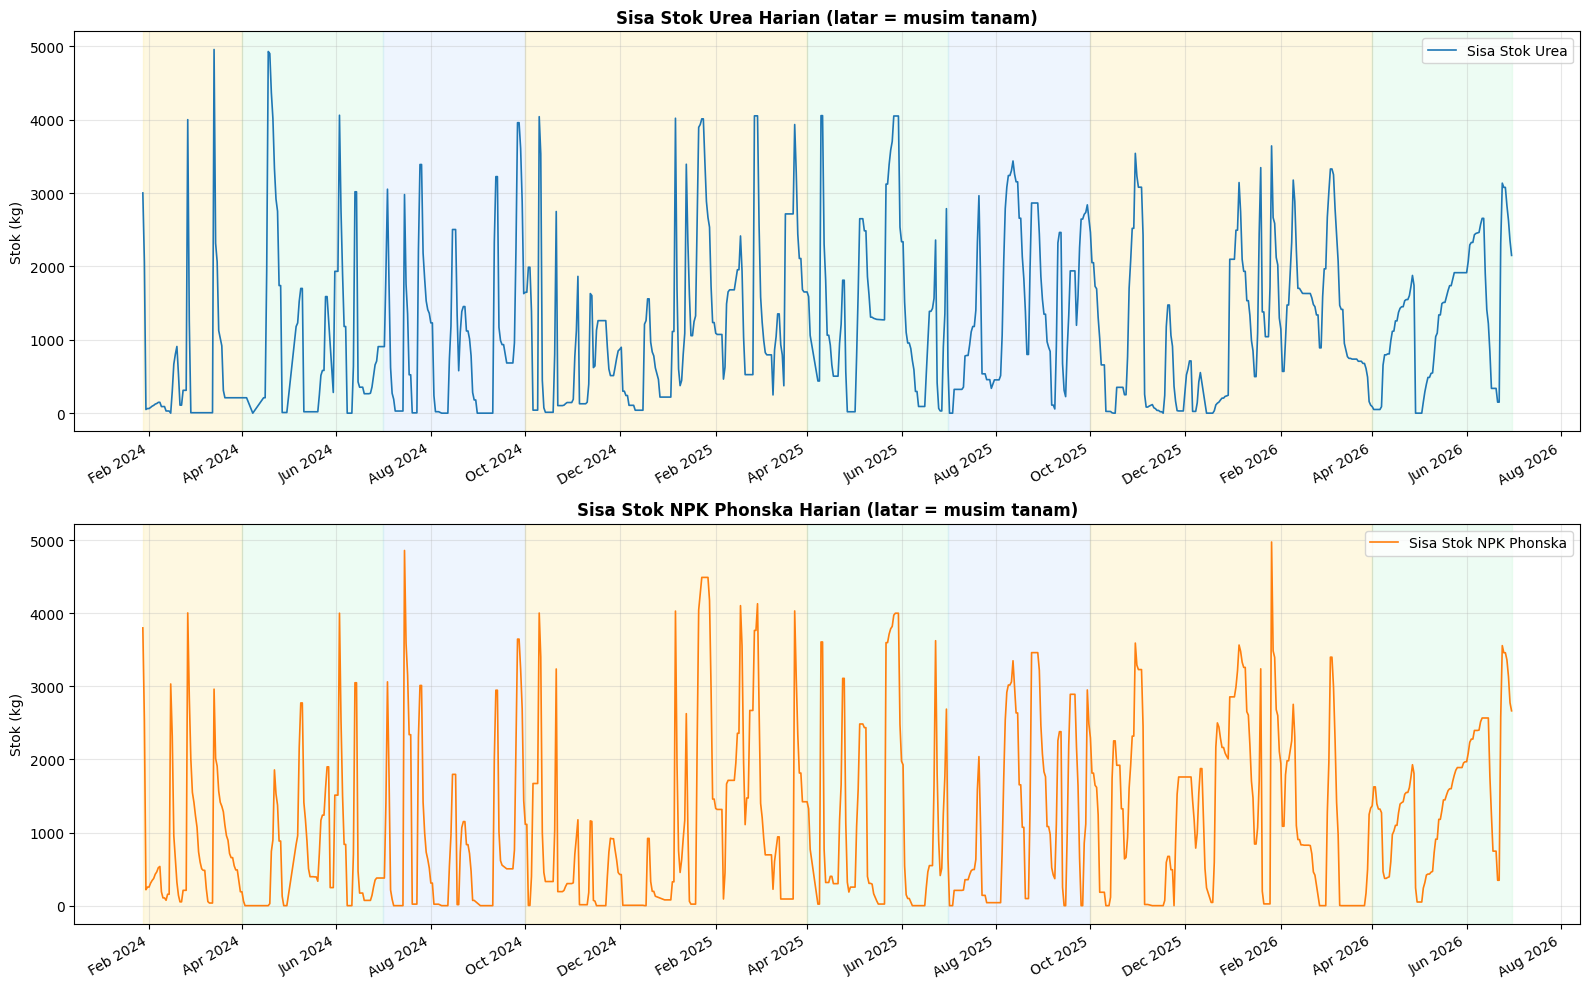

Grafik tersimpan sebagai grafik_sisa_stok_harian.png


In [ ]:
# CELL 4 - AUDIT DAN VISUALISASI DATA ( DENGAN MUSIM TANAM)

warna_musim = {"MT1": "#fde68a", "MT2": "#bbf7d0", "MT3": "#bfdbfe"}

fig, axes = plt.subplots(2, 1, figsize=(16, 10))


def shading_musim(ax):
    blok_awal = df_harian["tanggal"].iloc[0]
    musim_sebelumnya = df_harian["musim_tanam"].iloc[0]
    for i in range(1, len(df_harian)):
        musim_sekarang = df_harian["musim_tanam"].iloc[i]
        if musim_sekarang != musim_sebelumnya:
            ax.axvspan(blok_awal, df_harian["tanggal"].iloc[i], color=warna_musim[musim_sebelumnya], alpha=0.25)
            blok_awal = df_harian["tanggal"].iloc[i]
            musim_sebelumnya = musim_sekarang
    ax.axvspan(blok_awal, df_harian["tanggal"].iloc[-1], color=warna_musim[musim_sebelumnya], alpha=0.25)


shading_musim(axes[0])
axes[0].plot(df_harian["tanggal"], df_harian["stok_urea"], linewidth=1.2, label="Sisa Stok Urea")
axes[0].set_title("Sisa Stok Urea Harian (latar = musim tanam)", fontweight="bold")
axes[0].set_ylabel("Stok (kg)")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

shading_musim(axes[1])
axes[1].plot(df_harian["tanggal"], df_harian["stok_npk"], linewidth=1.2, label="Sisa Stok NPK Phonska", color="tab:orange")
axes[1].set_title("Sisa Stok NPK Phonska Harian (latar = musim tanam)", fontweight="bold")
axes[1].set_ylabel("Stok (kg)")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.savefig("grafik_sisa_stok_harian.png", dpi=150, bbox_inches="tight")
plt.show()

print("Grafik tersimpan sebagai grafik_sisa_stok_harian.png")

Matriks Korelasi (r):


,stok_urea,stok_npk,penyaluran_urea,penyaluran_npk,bulan_sin,bulan_cos,musim_mt1,musim_mt2,musim_mt3
stok_urea,1.000,0.736,0.134,0.150,0.045,-0.086,-0.084,0.045,0.052
stok_npk,0.736,1.000,0.159,0.198,0.017,0.026,0.011,-0.000,-0.013
penyaluran_urea,0.134,0.159,1.000,0.913,-0.033,0.062,0.051,-0.010,-0.051
penyaluran_npk,0.150,0.198,0.913,1.000,-0.048,0.049,0.029,0.005,-0.042
bulan_sin,0.045,0.017,-0.033,-0.048,1.000,-0.016,0.224,0.330,-0.652
bulan_cos,-0.086,0.026,0.062,0.049,-0.016,1.000,0.877,-0.693,-0.291
musim_mt1,-0.084,0.011,0.051,0.029,0.224,0.877,1.000,-0.646,-0.496
musim_mt2,0.045,-0.000,-0.010,0.005,0.330,-0.693,-0.646,1.000,-0.342
musim_mt3,0.052,-0.013,-0.051,-0.042,-0.652,-0.291,-0.496,-0.342,1.000



Matriks Koefisien Determinasi (R²):


,stok_urea,stok_npk,penyaluran_urea,penyaluran_npk,bulan_sin,bulan_cos,musim_mt1,musim_mt2,musim_mt3
stok_urea,1.000,0.542,0.018,0.023,0.002,0.007,0.007,0.002,0.003
stok_npk,0.542,1.000,0.025,0.039,0.000,0.001,0.000,0.000,0.000
penyaluran_urea,0.018,0.025,1.000,0.833,0.001,0.004,0.003,0.000,0.003
penyaluran_npk,0.023,0.039,0.833,1.000,0.002,0.002,0.001,0.000,0.002
bulan_sin,0.002,0.000,0.001,0.002,1.000,0.000,0.050,0.109,0.425
bulan_cos,0.007,0.001,0.004,0.002,0.000,1.000,0.769,0.480,0.085
musim_mt1,0.007,0.000,0.003,0.001,0.050,0.769,1.000,0.418,0.246
musim_mt2,0.002,0.000,0.000,0.000,0.109,0.480,0.418,1.000,0.117
musim_mt3,0.003,0.000,0.003,0.002,0.425,0.085,0.246,0.117,1.000


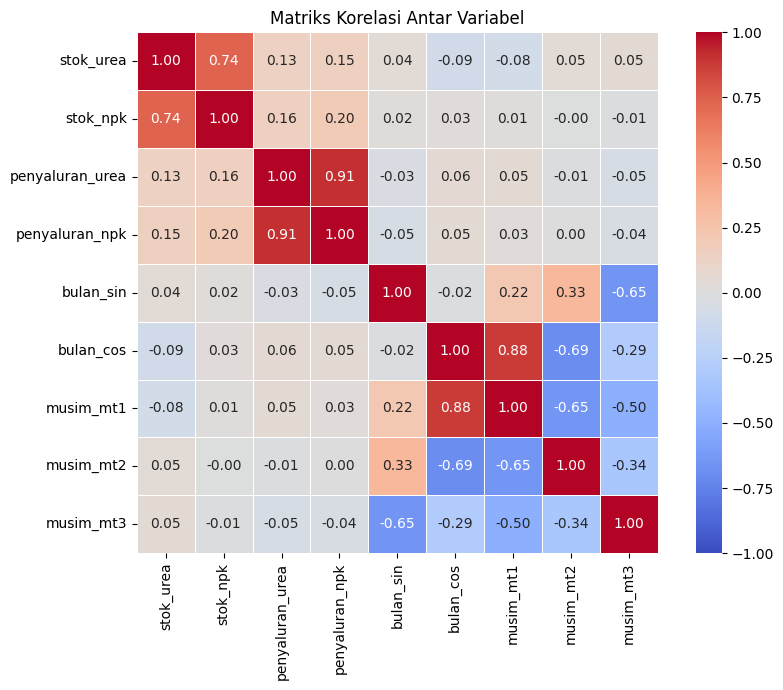


Korelasi & R² terhadap stok_urea (diurutkan):


,r,R2
stok_npk,0.736,0.542
penyaluran_npk,0.150,0.023
penyaluran_urea,0.134,0.018
musim_mt3,0.052,0.003
musim_mt2,0.045,0.002
bulan_sin,0.045,0.002
musim_mt1,-0.084,0.007
bulan_cos,-0.086,0.007



Korelasi & R² terhadap stok_npk (diurutkan):


,r,R2
stok_urea,0.736,0.542
penyaluran_npk,0.198,0.039
penyaluran_urea,0.159,0.025
bulan_cos,0.026,0.001
bulan_sin,0.017,0.000
musim_mt1,0.011,0.000
musim_mt2,-0.000,0.000
musim_mt3,-0.013,0.000


In [ ]:
# CELL 4B - ANALISIS KORELASI ANTAR VARIABEL

import seaborn as sns

kolom_analisis = [
    "stok_urea", "stok_npk",
    "penyaluran_urea", "penyaluran_npk",
    "bulan_sin", "bulan_cos",
    "musim_mt1", "musim_mt2", "musim_mt3"
]

df_corr = df_harian[kolom_analisis]

# Matriks korelasi Pearson (r)
corr_matrix = df_corr.corr(method="pearson")

# Matriks koefisien determinasi (R² = r²)
r2_matrix = corr_matrix ** 2

print("Matriks Korelasi (r):")
display(corr_matrix.round(3))
print("\nMatriks Koefisien Determinasi (R²):")
display(r2_matrix.round(3))

# Heatmap korelasi
plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Matriks Korelasi Antar Variabel")
plt.tight_layout()
plt.savefig("korelasi_heatmap.png", dpi=200)
plt.show()

# Fokus: korelasi & R² tiap fitur terhadap masing-masing target stok
print("\nKorelasi & R² terhadap stok_urea (diurutkan):")
ringkasan_urea = pd.DataFrame({
    "r": corr_matrix["stok_urea"],
    "R2": r2_matrix["stok_urea"]
}).drop("stok_urea").sort_values("r", ascending=False)
display(ringkasan_urea.round(3))

print("\nKorelasi & R² terhadap stok_npk (diurutkan):")
ringkasan_npk = pd.DataFrame({
    "r": corr_matrix["stok_npk"],
    "R2": r2_matrix["stok_npk"]
}).drop("stok_npk").sort_values("r", ascending=False)
display(ringkasan_npk.round(3))

In [ ]:
# CELL 5 - FUNGSI METRIK EVALUASI REGRESI

def hitung_metrik(aktual, prediksi):
    aktual = np.array(aktual, dtype=float)
    prediksi = np.array(prediksi, dtype=float)

    error = aktual - prediksi
    abs_error = np.abs(error)

    mae = np.mean(abs_error)
    rmse = np.sqrt(np.mean(error ** 2))

    mask_mape = aktual > 0
    mape = np.mean(np.abs((aktual[mask_mape] - prediksi[mask_mape]) / aktual[mask_mape])) * 100 if mask_mape.sum() > 0 else np.nan

    wmape = np.sum(abs_error) / np.sum(np.abs(aktual)) * 100 if np.sum(np.abs(aktual)) > 0 else np.nan

    denom = (np.abs(aktual) + np.abs(prediksi)) / 2
    mask_smape = denom > 0
    smape = np.mean(abs_error[mask_smape] / denom[mask_smape]) * 100 if mask_smape.sum() > 0 else np.nan

    try:
        r2 = r2_score(aktual, prediksi)
    except Exception:
        r2 = np.nan

    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "wMAPE": wmape, "SMAPE": smape, "R2": r2}


def kategori_wmape(wmape):
    if np.isnan(wmape):
        return "Tidak tersedia"
    elif wmape < 10:
        return "Sangat baik"
    elif wmape < 20:
        return "Baik"
    elif wmape < 30:
        return "Cukup"
    else:
        return "Kurang baik"
print("=" * 70)
print("  FUNGSI METRIK EVALUASI SIAP DIGUNAKAN")
print("=" * 70)
print("  Fungsi tersedia:")
print("  - hitung_metrik(aktual, prediksi)  -> MAE, RMSE, MAPE, wMAPE, SMAPE, R2")
print("  - kategori_wmape(wmape)            -> Sangat baik / Baik / Cukup / Kurang baik")

# Uji coba fungsi dengan contoh data stok Urea
contoh_aktual = [1631.00, 1571.29, 1481.06, 1451.00, 1338.80]
contoh_prediksi = [1596.36, 1603.97, 1602.31, 1483.91, 1377.80]

hasil_uji = hitung_metrik(contoh_aktual, contoh_prediksi)
print("\nContoh hasil uji fungsi (data stok Urea, kg):")
for k, v in hasil_uji.items():
    print(f"  {k:6s} = {v:.2f}")
print(f"  Kategori wMAPE = {kategori_wmape(hasil_uji['wMAPE'])}")

  FUNGSI METRIK EVALUASI SIAP DIGUNAKAN
  Fungsi tersedia:
  - hitung_metrik(aktual, prediksi)  -> MAE, RMSE, MAPE, wMAPE, SMAPE, R2
  - kategori_wmape(wmape)            -> Sangat baik / Baik / Cukup / Kurang baik

Contoh hasil uji fungsi (data stok Urea, kg):
  MAE    = 52.10
  RMSE   = 62.57
  MAPE   = 3.51
  wMAPE  = 3.49
  SMAPE  = 3.44
  R2     = 0.62
  Kategori wMAPE = Sangat baik


In [ ]:
#CELL 6 - FUNGSI SAFETY STOCK DAN STOK MINIMUM

LEAD_TIME_HARI = 4
Z_SERVICE_LEVEL = 1.645


def hitung_safety_stock_dari_penurunan(df, kolom_stok, z=1.645, lead_time_hari=4):
    temp = df[["tanggal", kolom_stok]].copy().sort_values("tanggal").reset_index(drop=True)
    temp["jarak_hari"] = temp["tanggal"].diff().dt.days
    temp["penurunan_stok"] = (temp[kolom_stok].shift(1) - temp[kolom_stok]).clip(lower=0)
    temp = temp[(temp["jarak_hari"] > 0) & (temp["penurunan_stok"].notna())].copy()
    temp["penurunan_harian"] = temp["penurunan_stok"] / temp["jarak_hari"]

    rata = temp["penurunan_harian"].mean()
    std = temp["penurunan_harian"].std(ddof=1)
    safety_stock = z * std * np.sqrt(lead_time_hari)
    kebutuhan_lead_time = rata * lead_time_hari
    stok_minimum = kebutuhan_lead_time + safety_stock

    return {
        "rata_penurunan_harian": rata,
        "std_penurunan_harian": std,
        "kebutuhan_lead_time": kebutuhan_lead_time,
        "safety_stock": safety_stock,
        "stok_minimum": stok_minimum
    }


ss_urea = hitung_safety_stock_dari_penurunan(df_harian, "stok_urea", z=Z_SERVICE_LEVEL, lead_time_hari=LEAD_TIME_HARI)
ss_npk = hitung_safety_stock_dari_penurunan(df_harian, "stok_npk", z=Z_SERVICE_LEVEL, lead_time_hari=LEAD_TIME_HARI)

df_safety_stock = pd.DataFrame([
    {"Jenis Pupuk": "Urea", "Lead Time (hari)": LEAD_TIME_HARI, "Service Level": "95%",
     "Rata Penurunan Harian (kg)": ss_urea["rata_penurunan_harian"],
     "Safety Stock (kg)": ss_urea["safety_stock"], "Stok Minimum (kg)": ss_urea["stok_minimum"]},
    {"Jenis Pupuk": "NPK Phonska", "Lead Time (hari)": LEAD_TIME_HARI, "Service Level": "95%",
     "Rata Penurunan Harian (kg)": ss_npk["rata_penurunan_harian"],
     "Safety Stock (kg)": ss_npk["safety_stock"], "Stok Minimum (kg)": ss_npk["stok_minimum"]}
])
for c in df_safety_stock.columns:
    if c not in ["Jenis Pupuk", "Service Level"]:
        df_safety_stock[c] = df_safety_stock[c].round(2)

display(df_safety_stock)

,Jenis Pupuk,Lead Time (hari),Service Level,Rata Penurunan Harian (kg),Safety Stock (kg),Stok Minimum (kg)
0,Urea,4,95%,151.83,1265.02,1872.33
1,NPK Phonska,4,95%,165.82,1373.13,2036.43


In [ ]:
# CELL 7 — FUNGSI LSTM REGRESI MULTIVARIAT TANPA DATA LEAKAGE

TRAIN_RATIO = 0.80
TEST_RATIO = 0.20
# Validasi untuk early stopping diambil otomatis dari 10% bagian akhir data
# training (via validation_split Keras), BUKAN split terpisah yang dilaporkan.
# Split resmi yang dilaporkan tetap 80% train : 20% test, sesuai rencana awal.
VALIDATION_SPLIT_INTERNAL = 0.10

BATCH_SIZE = 16
MAX_EPOCH = 300
PATIENCE = 35
LEARNING_RATE = 0.001

# Window lebih besar diikutkan karena hasil uji awal (Random Forest) menunjukkan
# performa terus membaik seiring window membesar hingga 30 hari.
TIMESTEPS_LIST = [7, 14, 21, 30]


def buat_sequence(data_scaled, window_size, kolom_target_idx=0):
    X, y, target_indices = [], [], []
    for i in range(len(data_scaled) - window_size):
        X.append(data_scaled[i:i + window_size, :])
        y.append(data_scaled[i + window_size, kolom_target_idx])
        target_indices.append(i + window_size)
    return np.array(X), np.array(y), np.array(target_indices)


def bangun_model_lstm(window_size, n_fitur):
    model = Sequential([
        LSTM(64, activation="tanh", return_sequences=True, input_shape=(window_size, n_fitur)),
        Dropout(0.20),
        LSTM(32, activation="tanh"),
        Dropout(0.20),
        Dense(16, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE), loss="mean_absolute_error")
    return model


def latih_lstm_regresi(df, kolom_target, nama_stok, window_size, fitur_eksogen):
    K.clear_session()
    tf.random.set_seed(42)
    np.random.seed(42)

    kolom_fitur = [kolom_target] + fitur_eksogen
    data = df[kolom_fitur].values.astype(float)
    tanggal = df["tanggal"].values

    n_total = len(data)
    n_train = int(n_total * TRAIN_RATIO)

    # Scaler hanya di-fit pada 80% data training (data 20% test tidak pernah
    # "dilihat" scaler, mencegah data leakage)
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaler.fit(data[:n_train])
    data_scaled = scaler.transform(data)

    X_all, y_all, target_indices = buat_sequence(data_scaled, window_size, kolom_target_idx=0)

    # Split resmi: 80% training, 20% testing (sesuai rencana awal penelitian)
    train_mask = target_indices < n_train
    test_mask = target_indices >= n_train

    X_train, y_train = X_all[train_mask], y_all[train_mask]
    X_test, y_test = X_all[test_mask], y_all[test_mask]
    tanggal_test = tanggal[target_indices[test_mask]]

    n_fitur = len(kolom_fitur)
    model = bangun_model_lstm(window_size, n_fitur)

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=12, min_lr=1e-5, verbose=0)
    ]

    # validation_split mengambil otomatis 10% BAGIAN AKHIR dari X_train/y_train
    # (karena shuffle=False) khusus untuk keperluan early stopping. Ini bukan
    # split resmi ketiga -- data test (20%) tetap terpisah total dan tidak
    # pernah dipakai sampai tahap evaluasi akhir.
    history = model.fit(
        X_train, y_train, validation_split=VALIDATION_SPLIT_INTERNAL,
        epochs=MAX_EPOCH, batch_size=BATCH_SIZE, callbacks=callbacks, verbose=0, shuffle=False
    )

    pred_scaled = model.predict(X_test, verbose=0)

    def inverse_kolom_target(nilai_scaled_1d):
        dummy = np.zeros((len(nilai_scaled_1d), n_fitur))
        dummy[:, 0] = nilai_scaled_1d
        return scaler.inverse_transform(dummy)[:, 0]

    aktual = inverse_kolom_target(y_test)
    prediksi = np.clip(inverse_kolom_target(pred_scaled.flatten()), 0, None)

    metrik = hitung_metrik(aktual, prediksi)

    df_pred = pd.DataFrame({
        "Tanggal": pd.to_datetime(tanggal_test),
        "Aktual (kg)": aktual.round(2),
        "Prediksi (kg)": prediksi.round(2),
        "Selisih Absolut (kg)": np.abs(aktual - prediksi).round(2)
    })

    return {
        "nama_stok": nama_stok, "kolom_target": kolom_target, "kolom_fitur": kolom_fitur,
        "window_size": window_size, "model": model, "history": history, "scaler": scaler,
        "metrik": metrik, "df_pred": df_pred,
        "epoch": len(history.history["loss"]),
        "train_loss": history.history["loss"][-1], "val_loss": history.history["val_loss"][-1]
    }

print("=" * 70)
print("  FUNGSI LSTM REGRESI SIAP DIGUNAKAN")
print("=" * 70)
print(f"  Parameter training: TRAIN_RATIO={TRAIN_RATIO}, TEST_RATIO={TEST_RATIO}")
print(f"  Total rasio: {TRAIN_RATIO + TEST_RATIO}")
print(f"  Timesteps yang akan diuji: {TIMESTEPS_LIST}")

  FUNGSI LSTM REGRESI SIAP DIGUNAKAN
  Parameter training: TRAIN_RATIO=0.8, TEST_RATIO=0.2
  Total rasio: 1.0
  Timesteps yang akan diuji: [7, 14, 21, 30]


In [ ]:
# CELL 8 - TRAINING LSTM REGRESI UNTUK BEBERAPA TIMESTEPS

hasil_semua = []
hasil_detail = {}

for nama_stok, kolom, fitur in [
    ("Stok Urea", "stok_urea", FITUR_EKSOGEN_UREA),
    ("Stok NPK Phonska", "stok_npk", FITUR_EKSOGEN_NPK)
]:
    print("\n" + "=" * 80)
    print(f"TRAINING MODEL LSTM REGRESI — {nama_stok.upper()}")
    print(f"Fitur eksogen: {fitur}")
    print("=" * 80)

    hasil_detail[nama_stok] = {}

    for ts in TIMESTEPS_LIST:
        hasil = latih_lstm_regresi(df_harian, kolom, nama_stok, ts, fitur)
        hasil_detail[nama_stok][ts] = hasil
        m = hasil["metrik"]

        hasil_semua.append({
            "Jenis Stok": nama_stok, "Timesteps": ts, "Epoch": hasil["epoch"],
            "Train Loss": hasil["train_loss"], "Val Loss": hasil["val_loss"],
            "MAE": m["MAE"], "RMSE": m["RMSE"], "MAPE": m["MAPE"], "wMAPE": m["wMAPE"],
            "SMAPE": m["SMAPE"], "R2": m["R2"], "Kategori wMAPE": kategori_wmape(m["wMAPE"])
        })

        print(f"Timesteps={ts:>2} | MAE={m['MAE']:>8.2f} kg | RMSE={m['RMSE']:>8.2f} kg | "
              f"wMAPE={m['wMAPE']:>7.2f}% | R2={m['R2']:>7.3f}")

df_evaluasi = pd.DataFrame(hasil_semua)
kolom_bulat = ["Train Loss", "Val Loss", "MAE", "RMSE", "MAPE", "wMAPE", "SMAPE", "R2"]
df_evaluasi[kolom_bulat] = df_evaluasi[kolom_bulat].round(4)

print("\nTabel evaluasi semua skenario LSTM regresi:")
display(df_evaluasi)


TRAINING MODEL LSTM REGRESI — STOK UREA
Fitur eksogen: ['penyaluran_urea', 'bulan_sin', 'bulan_cos', 'musim_mt1', 'musim_mt2', 'musim_mt3']
Timesteps= 7 | MAE=  211.23 kg | RMSE=  384.13 kg | wMAPE=  14.58% | R2=  0.802
Timesteps=14 | MAE=  210.99 kg | RMSE=  386.03 kg | wMAPE=  14.56% | R2=  0.800


Timesteps=21 | MAE=  217.71 kg | RMSE=  394.03 kg | wMAPE=  15.03% | R2=  0.792


Timesteps=30 | MAE=  216.63 kg | RMSE=  390.38 kg | wMAPE=  14.95% | R2=  0.796

TRAINING MODEL LSTM REGRESI — STOK NPK PHONSKA
Fitur eksogen: ['penyaluran_npk', 'bulan_sin', 'bulan_cos', 'musim_mt1', 'musim_mt2', 'musim_mt3']
Timesteps= 7 | MAE=  263.45 kg | RMSE=  581.56 kg | wMAPE=  19.29% | R2=  0.705
Timesteps=14 | MAE=  285.24 kg | RMSE=  594.08 kg | wMAPE=  20.88% | R2=  0.692
Timesteps=21 | MAE=  272.10 kg | RMSE=  576.51 kg | wMAPE=  19.92% | R2=  0.710
Timesteps=30 | MAE=  279.07 kg | RMSE=  588.80 kg | wMAPE=  20.43% | R2=  0.698

Tabel evaluasi semua skenario LSTM regresi:


,Jenis Stok,Timesteps,Epoch,Train Loss,Val Loss,MAE,RMSE,MAPE,wMAPE,SMAPE,R2,Kategori wMAPE
0,Stok Urea,7,103,0.0673,0.0509,211.2299,384.1256,17.9831,14.5802,23.1521,0.8024,Baik
1,Stok Urea,14,112,0.0659,0.0455,210.9950,386.0315,18.3981,14.5640,24.8444,0.8004,Baik
2,Stok Urea,21,114,0.0681,0.0464,217.7146,394.0310,19.0485,15.0279,22.3529,0.7921,Baik
3,Stok Urea,30,105,0.0681,0.0414,216.6278,390.3819,16.9597,14.9528,22.3901,0.7959,Baik
4,Stok NPK Phonska,7,104,0.0714,0.0577,263.4470,581.5638,189.5592,19.2860,48.1529,0.7053,Baik
5,Stok NPK Phonska,14,99,0.0712,0.0564,285.2422,594.0831,205.1159,20.8816,48.1469,0.6925,Cukup
6,Stok NPK Phonska,21,160,0.0683,0.0545,272.1021,576.5119,192.5264,19.9196,49.7519,0.7104,Baik
7,Stok NPK Phonska,30,195,0.0714,0.0528,279.0704,588.8023,185.0760,20.4297,49.8352,0.6979,Cukup


In [ ]:
# CELL 9 - PILIH MODEL TERBAIK BERDASARKAN wMAPE TERENDAH

df_best = (
    df_evaluasi.sort_values(["Jenis Stok", "wMAPE"], ascending=[True, True])
    .groupby("Jenis Stok").head(1).reset_index(drop=True)
)

print("=" * 80)
print("MODEL LSTM REGRESI TERBAIK PER JENIS STOK")
print("=" * 80)
display(df_best)

best_urea_ts = int(df_best.loc[df_best["Jenis Stok"] == "Stok Urea", "Timesteps"].iloc[0])
best_npk_ts = int(df_best.loc[df_best["Jenis Stok"] == "Stok NPK Phonska", "Timesteps"].iloc[0])

best_urea = hasil_detail["Stok Urea"][best_urea_ts]
best_npk = hasil_detail["Stok NPK Phonska"][best_npk_ts]

print(f"Timesteps terbaik Urea        : {best_urea_ts}")
print(f"Timesteps terbaik NPK Phonska : {best_npk_ts}")


MODEL LSTM REGRESI TERBAIK PER JENIS STOK


,Jenis Stok,Timesteps,Epoch,Train Loss,Val Loss,MAE,RMSE,MAPE,wMAPE,SMAPE,R2,Kategori wMAPE
0,Stok NPK Phonska,7,104,0.0714,0.0577,263.447,581.5638,189.5592,19.286,48.1529,0.7053,Baik
1,Stok Urea,14,112,0.0659,0.0455,210.995,386.0315,18.3981,14.564,24.8444,0.8004,Baik


Timesteps terbaik Urea        : 14
Timesteps terbaik NPK Phonska : 7


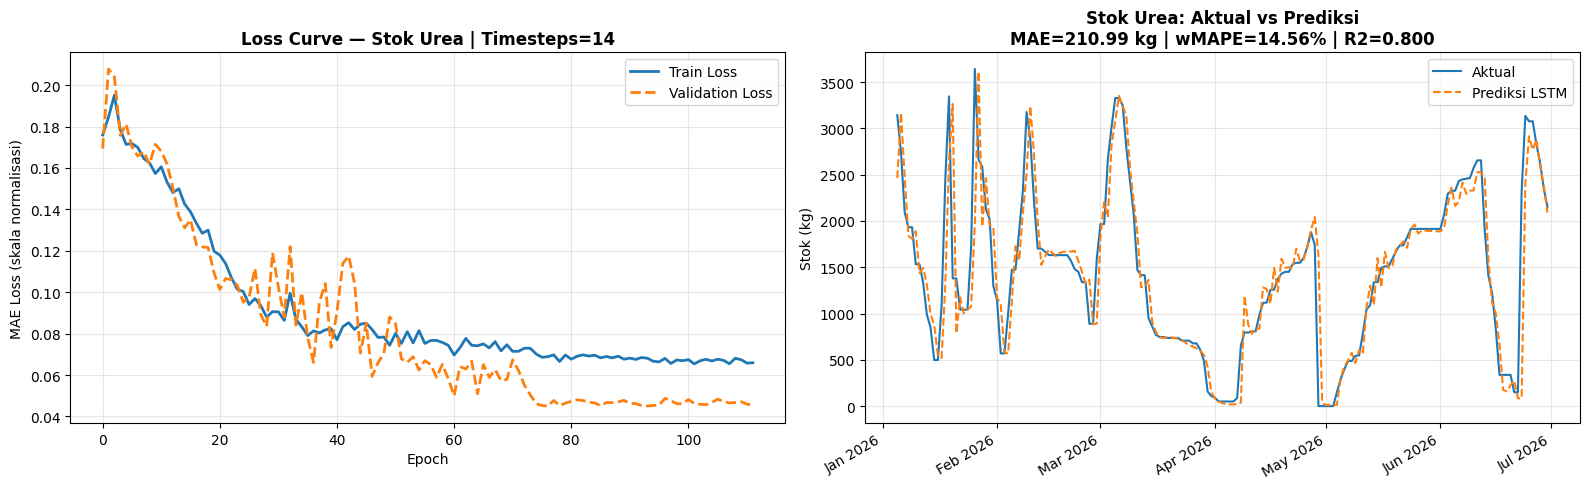

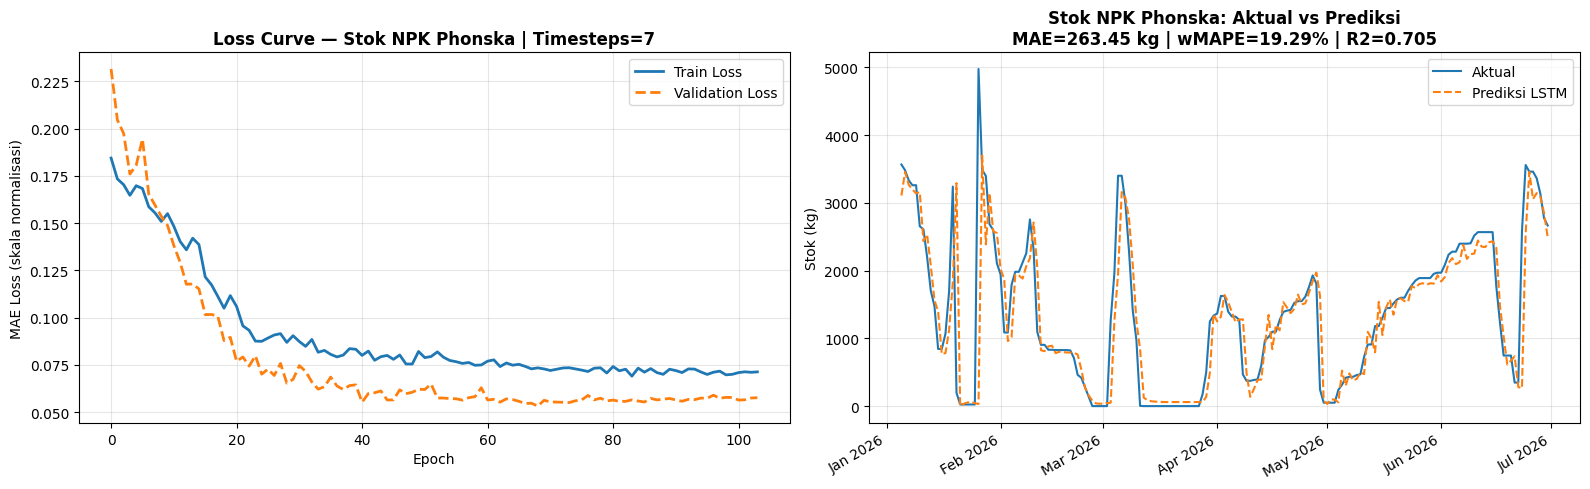

In [ ]:
# CELL 10 - VISUALISASI MODEL TERBAIK

def plot_hasil_model(hasil):
    nama, ts, hist, dfp, m = hasil["nama_stok"], hasil["window_size"], hasil["history"], hasil["df_pred"], hasil["metrik"]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].plot(hist.history["loss"], label="Train Loss", linewidth=2)
    axes[0].plot(hist.history["val_loss"], label="Validation Loss", linewidth=2, linestyle="--")
    axes[0].set_title(f"Loss Curve — {nama} | Timesteps={ts}", fontweight="bold")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("MAE Loss (skala normalisasi)")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(dfp["Tanggal"], dfp["Aktual (kg)"], label="Aktual", linewidth=1.5)
    axes[1].plot(dfp["Tanggal"], dfp["Prediksi (kg)"], label="Prediksi LSTM", linewidth=1.5, linestyle="--")
    axes[1].set_title(f"{nama}: Aktual vs Prediksi\nMAE={m['MAE']:.2f} kg | wMAPE={m['wMAPE']:.2f}% | R2={m['R2']:.3f}", fontweight="bold")
    axes[1].set_ylabel("Stok (kg)")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha="right")

    plt.tight_layout()
    plt.show()


plot_hasil_model(best_urea)
plot_hasil_model(best_npk)


In [ ]:
# CELL 11 - PREDIKSI PERIODE BERIKUTNYA DAN REKOMENDASI STOK

def prediksi_periode_berikutnya(hasil, df):
    model, scaler, ts, kolom_fitur = hasil["model"], hasil["scaler"], hasil["window_size"], hasil["kolom_fitur"]
    n_fitur = len(kolom_fitur)

    data = df[kolom_fitur].values.astype(float)
    last_window = data[-ts:]
    last_window_scaled = scaler.transform(last_window)
    X_next = last_window_scaled.reshape(1, ts, n_fitur)

    pred_scaled = model.predict(X_next, verbose=0)[0, 0]
    dummy = np.zeros((1, n_fitur))
    dummy[0, 0] = pred_scaled
    pred = max(scaler.inverse_transform(dummy)[0, 0], 0)
    return pred


def status_stok(prediksi_stok, stok_minimum):
    """
    Status stok berdasarkan posisi prediksi terhadap Stok Minimum (ROP):
    - "Waspada": prediksi stok < 120% dari Stok Minimum
                 (termasuk jika prediksi sudah di bawah Stok Minimum itu sendiri)
    - "Aman"   : prediksi stok >= 120% dari Stok Minimum
    """
    ambang_waspada = stok_minimum * 1.20
    if prediksi_stok < ambang_waspada:
        return "Waspada"
    else:
        return "Aman"


pred_urea_next = prediksi_periode_berikutnya(best_urea, df_harian)
pred_npk_next = prediksi_periode_berikutnya(best_npk, df_harian)

df_rekomendasi = pd.DataFrame([
    {"Jenis Pupuk": "Urea", "Tanggal Data Terakhir": df_harian["tanggal"].max().strftime("%d-%m-%Y"),
     "Prediksi Stok Periode Berikutnya (kg)": round(pred_urea_next, 2),
     "Safety Stock (kg)": round(ss_urea["safety_stock"], 2),
     "Stok Minimum (kg)": round(ss_urea["stok_minimum"], 2),
     "Status": status_stok(pred_urea_next, ss_urea["stok_minimum"])},
    {"Jenis Pupuk": "NPK Phonska", "Tanggal Data Terakhir": df_harian["tanggal"].max().strftime("%d-%m-%Y"),
     "Prediksi Stok Periode Berikutnya (kg)": round(pred_npk_next, 2),
     "Safety Stock (kg)": round(ss_npk["safety_stock"], 2),
     "Stok Minimum (kg)": round(ss_npk["stok_minimum"], 2),
     "Status": status_stok(pred_npk_next, ss_npk["stok_minimum"])}
])

print("=" * 80)
print("REKOMENDASI PERENCANAAN STOK BERDASARKAN HASIL LSTM REGRESI")
print("=" * 80)
display(df_rekomendasi)

REKOMENDASI PERENCANAAN STOK BERDASARKAN HASIL LSTM REGRESI


,Jenis Pupuk,Tanggal Data Terakhir,Prediksi Stok Periode Berikutnya (kg),Safety Stock (kg),Stok Minimum (kg),Status
0,Urea,30-06-2026,1910.85,1265.02,1872.33,Waspada
1,NPK Phonska,30-06-2026,2423.64,1373.13,2036.43,Waspada


In [ ]:
# CELL 12 - TABEL HASIL PREDIKSI TEST SET MODEL TERBAIK

print("Hasil prediksi test set Urea:")
display(best_urea["df_pred"].head(10))

print("Hasil prediksi test set NPK Phonska:")
display(best_npk["df_pred"].head(10))


Hasil prediksi test set Urea:


,Tanggal,Aktual (kg),Prediksi (kg),Selisih Absolut (kg)
0,2026-01-05,3143.00,2464.25,678.75
1,2026-01-06,2743.29,3166.59,423.30
2,2026-01-07,2095.93,2477.72,381.79
3,2026-01-08,1933.00,1840.59,92.41
4,2026-01-09,1933.00,1808.00,125.00
5,2026-01-10,1533.00,1888.21,355.21
6,2026-01-11,1533.00,1436.17,96.83
7,2026-01-12,1333.00,1493.16,160.16
8,2026-01-13,990.67,1311.86,321.19
9,2026-01-14,849.50,994.13,144.63


Hasil prediksi test set NPK Phonska:


,Tanggal,Aktual (kg),Prediksi (kg),Selisih Absolut (kg)
0,2026-01-05,3565.00,3107.05,457.95
1,2026-01-06,3479.96,3455.94,24.02
2,2026-01-07,3330.66,3263.86,66.80
3,2026-01-08,3259.00,3197.42,61.58
4,2026-01-09,3259.00,3138.20,120.80
5,2026-01-10,2653.29,3157.29,504.00
6,2026-01-11,2607.40,2434.21,173.19
7,2026-01-12,2199.00,2530.80,331.80
8,2026-01-13,1702.15,2077.16,375.01
9,2026-01-14,1476.65,1564.07,87.42


In [ ]:
# CELL 13 - EXPORT HASIL KE EXCEL

output_excel = "hasil_lstm_regresi_stok_pupuk_databaru.xlsx"

with pd.ExcelWriter(output_excel, engine="openpyxl") as writer:
    df_harian.to_excel(writer, sheet_name="Data Bersih", index=False)
    df_safety_stock.to_excel(writer, sheet_name="Safety Stock", index=False)
    df_evaluasi.to_excel(writer, sheet_name="Evaluasi LSTM", index=False)
    df_best.to_excel(writer, sheet_name="Model Terbaik", index=False)
    best_urea["df_pred"].to_excel(writer, sheet_name="Prediksi Urea", index=False)
    best_npk["df_pred"].to_excel(writer, sheet_name="Prediksi NPK", index=False)
    df_rekomendasi.to_excel(writer, sheet_name="Rekomendasi Stok", index=False)

print(f"File hasil berhasil dibuat: {output_excel}")

from google.colab import files
files.download(output_excel)

File hasil berhasil dibuat: hasil_lstm_regresi_stok_pupuk_databaru.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>